# Quantitative Portfolio Analyzer
### Daniel Hernandez

This project analyzes the historical performance and risk of a portfolio of stocks using Python. It compares individual assets and portfolio strategies using returns, volatility, diversification, and risk-adjusted performance metrics.

In [1]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tickers = ["AAPL", "MSFT", "JPM", "NVDA", "XOM"]

start_date = "2021-01-01"
end_date = "2026-01-01"

print("Portfolio assets:", tickers)

Portfolio assets: ['AAPL', 'MSFT', 'JPM', 'NVDA', 'XOM']


In [4]:
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
)

prices = data["Close"]

prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,JPM,MSFT,NVDA,XOM
Date,,,,,
2021-01-04,125.632545,109.000519,207.565353,13.046197,33.251320
2021-01-05,127.185783,109.593620,207.765610,13.335953,34.853798
2021-01-06,122.904533,114.739693,202.378387,12.549755,35.743179
2021-01-07,127.098412,118.507675,208.137497,13.275513,36.023605
2021-01-08,128.195450,118.638504,209.405640,13.208609,36.424221


In [5]:
normalized_prices = prices / prices.iloc[0] * 100

normalized_prices.head()

Ticker,AAPL,JPM,MSFT,NVDA,XOM
Date,,,,,
2021-01-04,100.000000,100.000000,100.000000,100.000000,100.000000
2021-01-05,101.236334,100.544127,100.096479,102.220998,104.819291
2021-01-06,97.828579,105.265272,97.501044,96.194739,107.494017
2021-01-07,101.166788,108.722120,100.275645,101.757721,108.337370
2021-01-08,102.040000,108.842146,100.886606,101.244897,109.542181


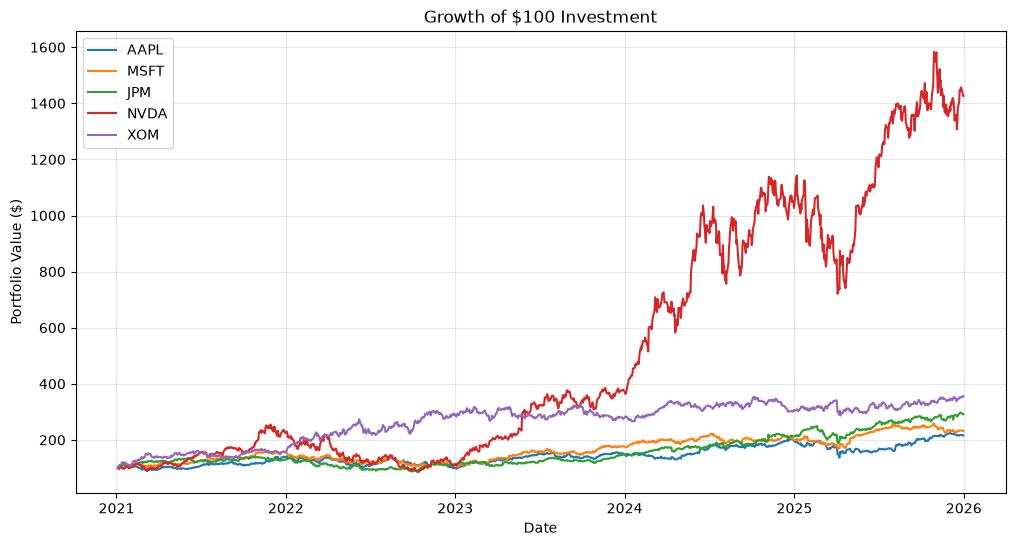

In [6]:
plt.figure(figsize=(12, 6))

for ticker in tickers:
    plt.plot(normalized_prices.index,
             normalized_prices[ticker],
             label=ticker)

plt.title("Growth of $100 Investment")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [7]:
daily_returns = prices.pct_change().dropna()

daily_returns.head()

Ticker,AAPL,JPM,MSFT,NVDA,XOM
Date,,,,,
2021-01-05,0.012363,0.005441,0.000965,0.022210,0.048193
2021-01-06,-0.033661,0.046956,-0.025929,-0.058953,0.025517
2021-01-07,0.034123,0.032839,0.028457,0.057830,0.007846
2021-01-08,0.008631,0.001104,0.006093,-0.005040,0.011121
2021-01-11,-0.023249,0.014924,-0.009699,0.025967,0.030357


In [8]:
trading_days = 252

annual_returns = daily_returns.mean() * trading_days
annual_volatility = daily_returns.std() * np.sqrt(trading_days)

performance = pd.DataFrame({
    "Annual Return": annual_returns,
    "Annual Volatility": annual_volatility
})

performance

,Annual Return,Annual Volatility
Ticker,,
AAPL,0.193226,0.278626
JPM,0.244470,0.242746
MSFT,0.201725,0.257143
NVDA,0.669495,0.522247
XOM,0.291140,0.270234


In [9]:
risk_free_rate = 0.04

sharpe_ratio = (
    (annual_returns - risk_free_rate)
    / annual_volatility
)

performance["Sharpe Ratio"] = sharpe_ratio

performance

,Annual Return,Annual Volatility,Sharpe Ratio
Ticker,,,
AAPL,0.193226,0.278626,0.549934
JPM,0.244470,0.242746,0.842319
MSFT,0.201725,0.257143,0.628932
NVDA,0.669495,0.522247,1.205359
XOM,0.291140,0.270234,0.929342


In [10]:
performance_display = performance.copy()

performance_display["Annual Return"] = (
    performance_display["Annual Return"] * 100
)

performance_display["Annual Volatility"] = (
    performance_display["Annual Volatility"] * 100
)

performance_display.columns = [
    "Annual Return (%)",
    "Annual Volatility (%)",
    "Sharpe Ratio"
]

performance_display.round(2)

,Annual Return (%),Annual Volatility (%),Sharpe Ratio
Ticker,,,
AAPL,19.32,27.86,0.55
JPM,24.45,24.27,0.84
MSFT,20.17,25.71,0.63
NVDA,66.95,52.22,1.21
XOM,29.11,27.02,0.93


In [11]:
correlation_matrix = daily_returns.corr()

correlation_matrix.round(2)

Ticker,AAPL,JPM,MSFT,NVDA,XOM
Ticker,,,,,
AAPL,1.00,0.35,0.63,0.52,0.19
JPM,0.35,1.00,0.31,0.32,0.36
MSFT,0.63,0.31,1.00,0.63,0.08
NVDA,0.52,0.32,0.63,1.00,0.09
XOM,0.19,0.36,0.08,0.09,1.00


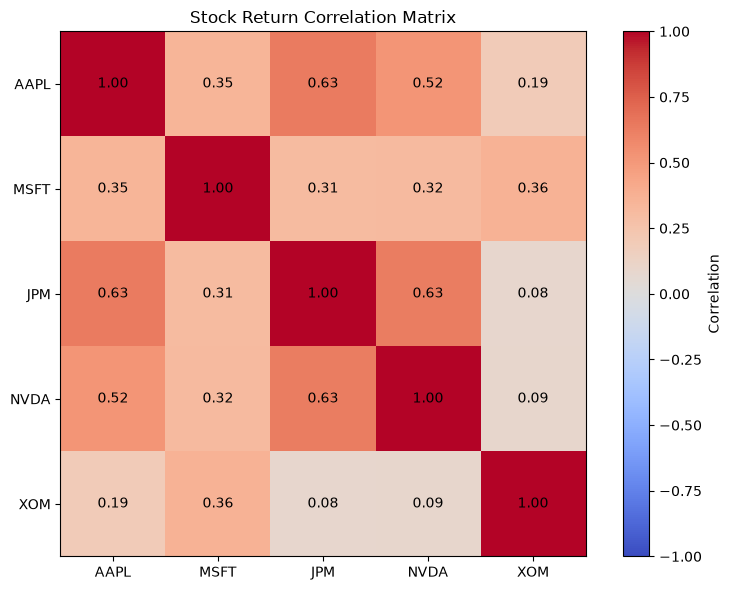

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

heatmap = ax.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))

ax.set_xticklabels(tickers)
ax.set_yticklabels(tickers)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(heatmap, label="Correlation")
plt.title("Stock Return Correlation Matrix")
plt.tight_layout()
plt.show()

In [13]:
weights = np.array([1 / len(prices.columns)] * len(prices.columns))

portfolio_daily_returns = daily_returns.dot(weights)

portfolio_annual_return = portfolio_daily_returns.mean() * trading_days
portfolio_volatility = portfolio_daily_returns.std() * np.sqrt(trading_days)

portfolio_sharpe = (
    (portfolio_annual_return - risk_free_rate)
    / portfolio_volatility
)

print(f"Annual Return: {portfolio_annual_return * 100:.2f}%")
print(f"Annual Volatility: {portfolio_volatility * 100:.2f}%")
print(f"Sharpe Ratio: {portfolio_sharpe:.2f}")

Annual Return: 32.00%
Annual Volatility: 22.25%
Sharpe Ratio: 1.26


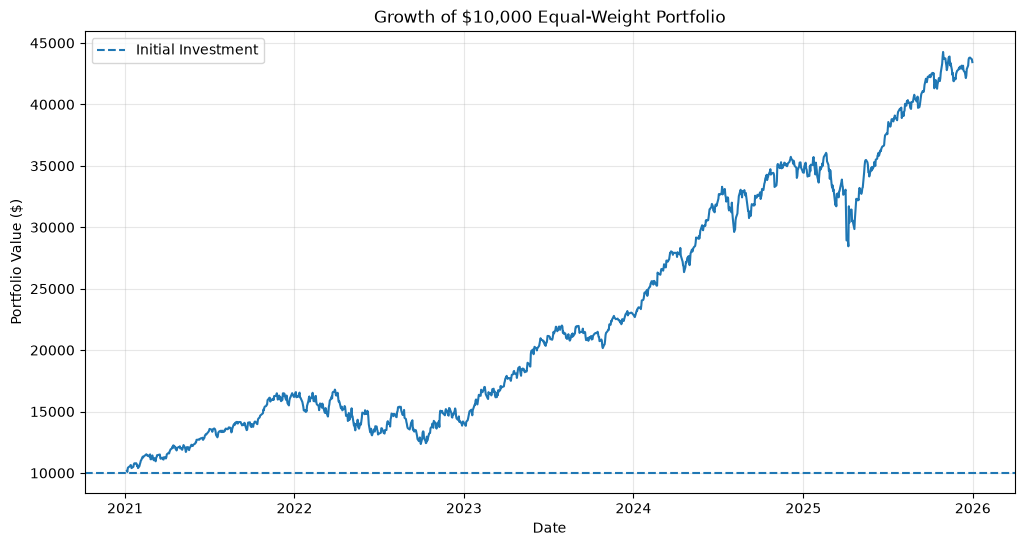

In [14]:
initial_investment = 10000

portfolio_growth = (
    initial_investment * (1 + portfolio_daily_returns).cumprod()
)

plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_growth.index,
    portfolio_growth
)

plt.axhline(
    initial_investment,
    linestyle="--",
    label="Initial Investment"
)

plt.title("Growth of $10,000 Equal-Weight Portfolio")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [15]:
running_max = portfolio_growth.cummax()

drawdown = (
    portfolio_growth - running_max
) / running_max

max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown * 100:.2f}%")

Maximum Drawdown: -26.40%


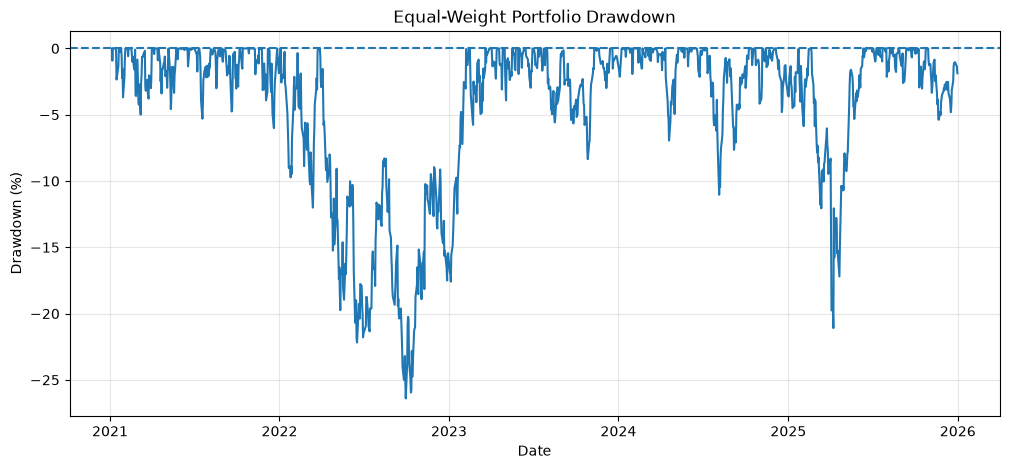

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    drawdown.index,
    drawdown * 100
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Equal-Weight Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True, alpha=0.3)

plt.show()

In [17]:
num_portfolios = 10000

np.random.seed(42)

results = []

for i in range(num_portfolios):
    
    # Generate random portfolio weights
    weights = np.random.random(len(prices.columns))
    weights = weights / np.sum(weights)
    
    # Expected annual return
    portfolio_return = np.sum(
        weights * annual_returns
    )
    
    # Annual portfolio volatility
    covariance_matrix = daily_returns.cov() * trading_days
    
    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(covariance_matrix, weights)
        )
    )
    
    # Sharpe ratio
    portfolio_sharpe = (
        (portfolio_return - risk_free_rate)
        / portfolio_volatility
    )
    
    results.append([
        portfolio_return,
        portfolio_volatility,
        portfolio_sharpe,
        *weights
    ])

In [18]:
columns = [
    "Return",
    "Volatility",
    "Sharpe",
    *prices.columns
]

simulation_results = pd.DataFrame(
    results,
    columns=columns
)

simulation_results.head()

,Return,Volatility,Sharpe,AAPL,JPM,MSFT,NVDA,XOM
0,0.319595,0.234226,1.193694,0.133197,0.338101,0.260318,0.212900,0.055485
1,0.346384,0.240194,1.275566,0.065285,0.024308,0.362501,0.251571,0.296334
2,0.272479,0.205806,1.129600,0.009284,0.437468,0.375464,0.095773,0.082010
3,0.339741,0.239255,1.252812,0.105673,0.175297,0.302353,0.248877,0.167800
4,0.315832,0.228783,1.205652,0.327909,0.074759,0.156568,0.196343,0.244421


In [19]:
max_sharpe_index = simulation_results["Sharpe"].idxmax()
min_volatility_index = simulation_results["Volatility"].idxmin()

max_sharpe_portfolio = simulation_results.loc[max_sharpe_index]
min_volatility_portfolio = simulation_results.loc[min_volatility_index]

print("Maximum Sharpe Portfolio:")
print(max_sharpe_portfolio)

print("\nMinimum Volatility Portfolio:")
print(min_volatility_portfolio)

Maximum Sharpe Portfolio:
Return        0.418118
Volatility    0.257802
Sharpe        1.466701
AAPL          0.006082
JPM           0.146708
MSFT          0.033412
NVDA          0.363173
XOM           0.450625
Name: 5445, dtype: float64

Minimum Volatility Portfolio:
Return        0.244252
Volatility    0.181091
Sharpe        1.127899
AAPL          0.132087
JPM           0.273411
MSFT          0.270192
NVDA          0.007836
XOM           0.316474
Name: 8610, dtype: float64


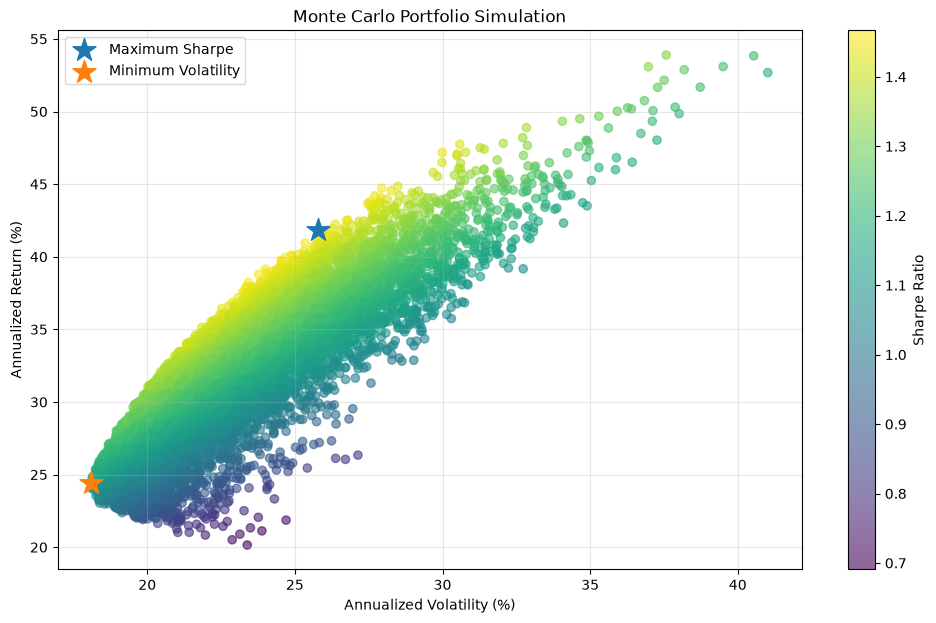

In [20]:
plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    simulation_results["Volatility"] * 100,
    simulation_results["Return"] * 100,
    c=simulation_results["Sharpe"],
    cmap="viridis",
    alpha=0.6
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.scatter(
    max_sharpe_portfolio["Volatility"] * 100,
    max_sharpe_portfolio["Return"] * 100,
    marker="*",
    s=300,
    label="Maximum Sharpe"
)

plt.scatter(
    min_volatility_portfolio["Volatility"] * 100,
    min_volatility_portfolio["Return"] * 100,
    marker="*",
    s=300,
    label="Minimum Volatility"
)

plt.title("Monte Carlo Portfolio Simulation")
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [21]:
asset_columns = list(prices.columns)

max_sharpe_weights = (
    max_sharpe_portfolio[asset_columns] * 100
)

min_volatility_weights = (
    min_volatility_portfolio[asset_columns] * 100
)

allocation_table = pd.DataFrame({
    "Max Sharpe Portfolio (%)": max_sharpe_weights,
    "Minimum Volatility Portfolio (%)": min_volatility_weights
})

allocation_table.round(2)

,Max Sharpe Portfolio (%),Minimum Volatility Portfolio (%)
AAPL,0.61,13.21
JPM,14.67,27.34
MSFT,3.34,27.02
NVDA,36.32,0.78
XOM,45.06,31.65


In [22]:
spy_data = yf.download(
    "SPY",
    start=start_date,
    end=end_date,
    auto_adjust=True
)

spy_prices = spy_data["Close"].squeeze()

spy_returns = spy_prices.pct_change().dropna()

spy_growth = (
    initial_investment * (1 + spy_returns).cumprod()
)

[*********************100%***********************]  1 of 1 completed


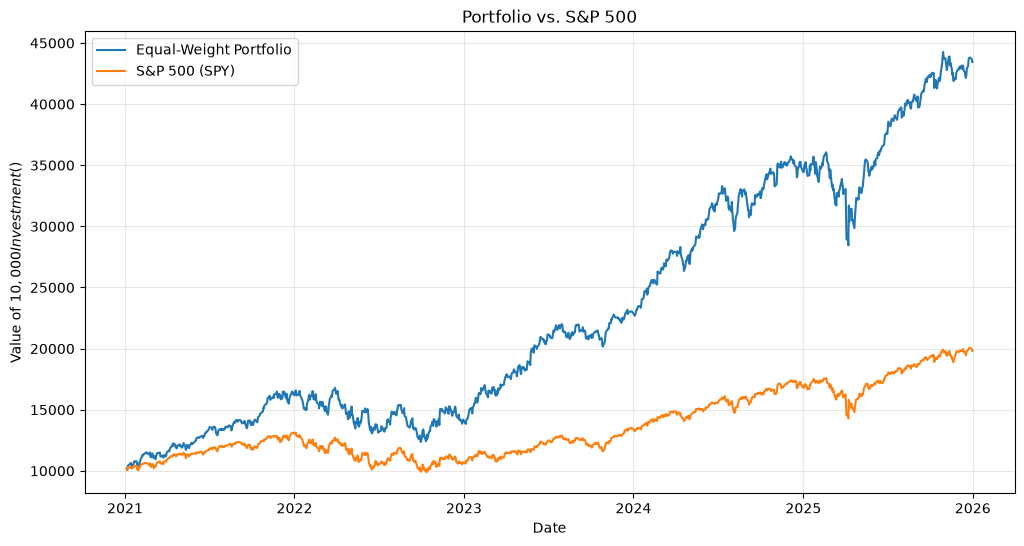

In [23]:
plt.figure(figsize=(12, 6))

plt.plot(
    portfolio_growth.index,
    portfolio_growth,
    label="Equal-Weight Portfolio"
)

plt.plot(
    spy_growth.index,
    spy_growth,
    label="S&P 500 (SPY)"
)

plt.title("Portfolio vs. S&P 500")
plt.xlabel("Date")
plt.ylabel("Value of $10,000 Investment ($)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [24]:
years = (
    portfolio_growth.index[-1] -
    portfolio_growth.index[0]
).days / 365.25

portfolio_cagr = (
    portfolio_growth.iloc[-1] / initial_investment
) ** (1 / years) - 1

spy_cagr = (
    spy_growth.iloc[-1] / initial_investment
) ** (1 / years) - 1

print(f"Portfolio CAGR: {portfolio_cagr * 100:.2f}%")
print(f"S&P 500 CAGR: {spy_cagr * 100:.2f}%")

Portfolio CAGR: 34.26%
S&P 500 CAGR: 14.69%


In [25]:
spy_annual_return = spy_returns.mean() * trading_days
spy_volatility = spy_returns.std() * np.sqrt(trading_days)

spy_sharpe = (
    (spy_annual_return - risk_free_rate)
    / spy_volatility
)

spy_running_max = spy_growth.cummax()

spy_drawdown = (
    spy_growth - spy_running_max
) / spy_running_max

spy_max_drawdown = spy_drawdown.min()

comparison = pd.DataFrame({
    "Equal-Weight Portfolio": [
        portfolio_cagr * 100,
        portfolio_volatility * 100,
        portfolio_sharpe,
        max_drawdown * 100
    ],
    "S&P 500 (SPY)": [
        spy_cagr * 100,
        spy_volatility * 100,
        spy_sharpe,
        spy_max_drawdown * 100
    ]
}, index=[
    "CAGR (%)",
    "Annualized Volatility (%)",
    "Sharpe Ratio",
    "Maximum Drawdown (%)"
])

comparison.round(2)

,Equal-Weight Portfolio,S&P 500 (SPY)
CAGR (%),34.26,14.69
Annualized Volatility (%),21.79,17.11
Sharpe Ratio,1.24,0.65
Maximum Drawdown (%),-26.40,-24.50


## Results and Conclusions

This project analyzed a five-stock portfolio consisting of AAPL, MSFT, JPM, NVDA, and XOM using historical market data from 2021 through 2025.

### Key Results

- A 10,000 equal-weight portfolio grew to approximately 43,000 over the analysis period.
- The equal-weight portfolio achieved a CAGR of approximately 34.3%, compared with 14.7% for the S&P 500 (SPY).
- The portfolio experienced higher annualized volatility than SPY (25.1% vs. 17.1%).
- The portfolio's maximum drawdown was approximately -26.4%, compared with -24.5% for SPY.
- Using an assumed 4% risk-free rate, the portfolio produced a historical Sharpe ratio of approximately 1.33.
- Correlation analysis showed that combining assets from different sectors can reduce portfolio volatility through diversification.
- A Monte Carlo simulation of 10,000 portfolio allocations demonstrated the tradeoff between expected return and volatility and identified simulated maximum-Sharpe and minimum-volatility portfolios.

### Limitations

This analysis is based entirely on historical data and does not predict future investment performance. The selected stocks were not chosen through an out-of-sample investment strategy, so comparisons with the S&P 500 should not be interpreted as evidence that the portfolio will outperform the market. Transaction costs, taxes, changing interest rates, and other real-world factors are also excluded.